# Langgraph Chatbot With Tools

In [2]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
os.environ['TAVILY_API_KEY'] = os.getenv('TAVILY_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

# 도구 정의

In [3]:
# Tavily Search 도구 생성 및 검색

from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(max_results=3)
tavily_tool.invoke('랭그래프의 노드와 엣지가 뭐야?')

{'query': '랭그래프의 노드와 엣지가 뭐야?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://databoom.tistory.com/entry/LangGraph-%EB%85%B8%EB%93%9Cnode%EC%99%80-%EC%97%A3%EC%A7%80edge',
   'title': '[LangGraph] 노드(node)와 엣지(edge) - 인공지능 개발자 수다 - 티스토리',
   'content': '2.1. 엣지 개념. 엣지는 노드와 노드를 연결하는 경로다. 데이터가 한 노드에서 다음 노드로 흘러가는 길이라고 보면 된다.',
   'score': 0.852752,
   'raw_content': None,
   'id': '779614-00'},
  {'url': 'https://velog.io/@ohback/LangGraph',
   'title': 'LangGraph란 무엇이고 언제 쓰면 좋을까?',
   'content': '위 코드에서 상태, 노드, 엣지는 다음과 같다.\n\n 상태(State): 질문, 후보 문서 목록, 현재까지의 답변, 재시도 횟수 등\n 노드(Nodes): `retrieve`, `grade_docs`, `generate`, `decide_more`\n 엣지(Edges): `START → retrieve → grade_docs → generate → decide_more → (END 또는 retrieve로 루프)`\n\n간단히 말해서, 노드는 작업을 수행하고, 에지는 다음에 무엇을 할지 알려준다.\n\n  \n\n## 핵심 활용 분야\n\nLangGraph의 강점은 상태 기반(Stateful) LLM 오케스트레이션이다.  \n 이러한 강점을 활용한 예시는 다음과 같다: [...] 여기서 등장하는 게 LangGraph다. 이름 그대로 그래프(노드/엣지)로 LLM 애플리케이션의 흐름을 설계한다.  \n La

# 그래프 구성

In [23]:
from typing import TypedDict, Annotated, List       # 타입 힌트 도구
from langgraph.graph.message import add_messages    # 메시지 누적 처리를 해줄 헬퍼
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List, add_messages] # messages 필드가 add_messages 규칙으로 누적 저장

llm = init_chat_model('gpt-5.4-mini')
tools = [tavily_tool]
llm_with_tools = llm.bind_tools(tools) # llm에 도구 스펙 바인딩

# State의 messages 를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    response = llm_with_tools.invoke(state['messages']) # 누적된 메시지 리스트로 LLM 호출
    return {'messages': [response]} # add_messages 규칙에 의해 기존 messages에 응답이 누적됨.    

In [22]:
from langchain_core.messages import ToolMessage # 툴 실행 결과를 담을 메시지 타입
import json # json 문자열 파싱

# tool call을 실행하는 노드 클래스
class ToolNode:
    def __init__(self, tools):
        self.tools_by_name = {tool.name : tool for tool in tools} # {tool_name: tool 객체}

    def __call__(self, inputs: State):
        """
        도구 호출을 처리하는 메서드입니다.

        Args:
            inputs (dict): 입력 상태 딕셔너리. 'messages' 키에 메시지 리스트가 포함되어야 합니다.

        Returns:
            dict: 도구 실행 결과를 담은 메시지 리스트가 포함된 딕셔너리.
                 형식: {"messages": [ToolMessage, ...]}

        Raises:
            ValueError: 입력에 메시지가 없는 경우 발생합니다.  
        """
        
        #messages 가 있으면 마지막 메시지 가져오고, 아니면 에러발생
        if messages := inputs.get("messages"):
            message = messages[-1] # 마지막 메시지(AI Message) 는 도구 호출 대상
        else:
            raise ValueError("메시지가 없습니다.")   

        outputs =[] # ToolMessage 들을 담을 리스트

        # 마지막 메시지(AI Message)에 포함된 tool_calls를 순회 
        for tool_call in message.tool_calls: 
            # tool 이름을 찾아 실행 (매개변수는 ai 메시지에서 전달한 입력 매개변수)
            tool_result = self.tools_by_name[tool_call['name']].invoke(tool_call['args'])
            tool_message = ToolMessage(
                content = json.dumps(tool_result, ensure_ascii=False, default=str), # 결과를 JSON 문자열로 변환
                name = tool_call['name'],
                tool_call_id = tool_call['id']
            )

            outputs.append(tool_message)

        return {"messages" : outputs}

In [16]:
# 도구 호출 여보에 따른 분기 함수(tools_condition) 
# 다음 분기로 tools 로 보낼지 아니면 END로 끌낼지 결정
from pprint import pprint

def tools_condition(state : State):
    if isinstance(state, list): # state가 list 형태(MessageGraph)인 경우
        messages = state
    else: # state가 dict 형태(StateGraph)인 경우
        messages = state.get("messages", [])

    if not messages:
        raise ValueError(f"State의 tool_edge에서 들어온 메시지 확인불가: {state}")

    pprint(messages)
    ai_message = messages[-1] # 마지막 메시지는 AIMessage

    # AIMessage 에 tool_calls가 있으면 도구 노드로 이동
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return 'tools'

    # tool_calls 가 없으면 END 노드로 이동
    return END 

<class 'langgraph.graph.state.CompiledStateGraph'>


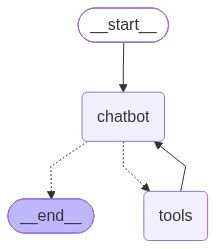

In [17]:
# 직접 구현한 ToolNode와 tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot') # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot) # chatbot 노드
workflow.add_node('tools', tool_node) # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools':'tools', END:END})
workflow.add_edge('tools','chatbot')

graph = workflow.compile() # 설계된 워크 플로우를 실행 가능한 그래프로 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

<class 'langgraph.graph.state.CompiledStateGraph'>


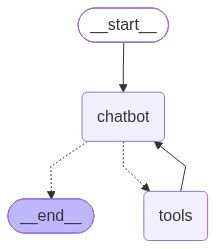

In [26]:
# langgraph.prebuilt 모듈의 ToolNode, tools_condition 함수 사용한 워크플로우
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

workflow = StateGraph(State) # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

workflow.add_edge(START, 'chatbot') # 시작 노드 -> chatbot 노드

workflow.add_node('chatbot', chatbot) # chatbot 노드
workflow.add_node('tools', tool_node) # tools 노드

workflow.add_conditional_edges('chatbot', tools_condition, {'tools':'tools', END:END})
workflow.add_edge('tools','chatbot')

graph = workflow.compile() # 설계된 워크 플로우를 실행 가능한 그래프로 컴파일
print(type(graph)) # 그래프 타입 확인
graph # 그래프 객체

In [27]:
user_query = '랭그래프의 구성요소는?'

state = {'messages' : [HumanMessage(content=user_query)]} # HumanMessage 객체 내 메세지 구현

response = graph.invoke(state) # 그래프 실행(START -> CHATBOT -> (tool 루프) or END)
pprint(response)
print('=' * 100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='랭그래프의 구성요소는?', additional_kwargs={}, response_metadata={}, id='84af4112-c525-40f1-8484-abb8612fc053'),
              AIMessage(content='랭그래프(LangGraph)의 주요 구성요소는 보통 아래처럼 이해하면 됩니다.\n\n1. **노드(Node)**  \n   - 그래프 안에서 실행되는 개별 작업 단위입니다.  \n   - 예: LLM 호출, 도구 실행, 검색, 요약, 분기 판단 등\n\n2. **엣지(Edge)**  \n   - 노드와 노드를 연결하는 흐름입니다.  \n   - 어떤 노드 다음에 어떤 노드로 갈지 결정합니다.\n\n3. **상태(State)**  \n   - 그래프가 실행되는 동안 공유되는 데이터입니다.  \n   - 예: 메시지 목록, 중간 결과, 사용자 정보, 작업 플래그 등  \n   - LangGraph의 핵심은 이 상태를 기반으로 여러 단계의 작업을 관리하는 것입니다.\n\n4. **시작점 / 종료점(Entry / Exit point)**  \n   - 그래프가 어디서 시작하고 어디서 끝나는지 정의합니다.\n\n5. **조건부 엣지(Conditional Edge)**  \n   - 상태나 판단 결과에 따라 다음 노드를 동적으로 선택합니다.  \n   - 예: “검색이 필요하면 search 노드로, 아니면 바로 답변 노드로”\n\n6. **체크포인트(Checkpoint, 선택적)**  \n   - 실행 중간 상태를 저장해 복구하거나 이어서 실행할 수 있게 합니다.  \n   - 대화형 에이전트나 장기 실행 워크플로우에서 유용합니다.\n\n7. **서브그래프(Subgraph, 선택적)**  \n   - 큰 그래프 안에 작은 그래프를 넣어 복잡한 로직을 모듈화할 수 있습니다.\n\n한 줄로 요약하면, **LangGraph는 상태를 공유하는 노드들과 그 사이의 연결(엣지)로

In [28]:
user_query = '최근 우리나라 산불 횟수?'

state = {'messages': [HumanMessage(content=user_query)]} # HumanMessage 객체 내 메시지 구현

response = graph.invoke(state) # 그래프 실행 (START -> CHATBOT -> (tool 루프) or END)
pprint(response)

print("="*100)
print(response['messages'][-1].content)

{'messages': [HumanMessage(content='최근 우리나라 산불 횟수?', additional_kwargs={}, response_metadata={}, id='b6da9757-0c9e-4c2c-a467-7ca8a9e58e9f'),
              AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 1277, 'total_tokens': 1348, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 1152, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJqi5Iaapz5APphxrIqcUTo8utfHW', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a064eb-9a4e-78f0-a268-f11668c9447d-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': '최근 우리나라 산불 횟수 한국 산불 발생 건수 최근 연도 산림청', 'search_de